### Dataset: Mall Customer Segmentation Dataset

In [1]:
# Required libraries install karne (run only once)
!pip install pandas numpy matplotlib seaborn scikit-learn mlxtend


[notice] A new release of pip available: 22.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Import Libraries

In [4]:
# Data handling sathi libraries
import pandas as pd
import numpy as np

# Visualization sathi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning sathi
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#### Load Dataset

In [ ]:
# CSV file load karne (file same folder madhye asel tar direct load hoil)
df = pd.read_csv("Mall_Customers.csv")

# First 5 rows 
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
# Dataset madhye kiti rows ani columns aahet
print("Shape:", df.shape) # Rows and columns count

# Data types ani null values check karne
df.info() # Data types and null values

# Statistical summary (mean, min, max, etc.)
df.describe() # Mean, min, max, etc.

Shape: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### EDA (Exploratory Data Analysis)

👉 ML (Machine Learning) madhe EDA म्हणजे model banvaycha aadhi data samjun gheaychi important step.

##### ML madhe EDA ka important ahe?

Data kasha type cha ahe te kalta (numerical / categorical)  
Missing values ahet ka te check karta  
Outliers (khup jast/kami values) find karta  
Features madhla relation samajta (e.g. study hours vs marks)  

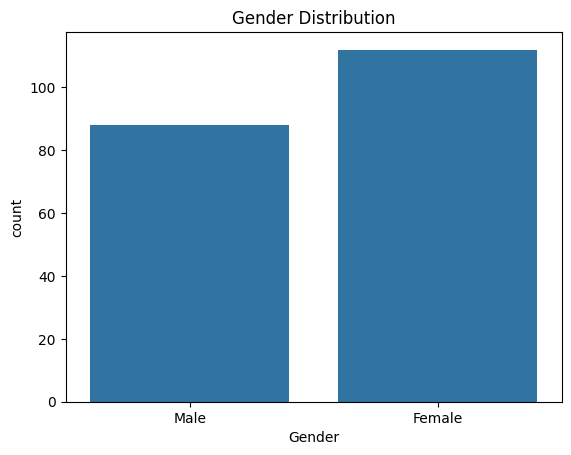

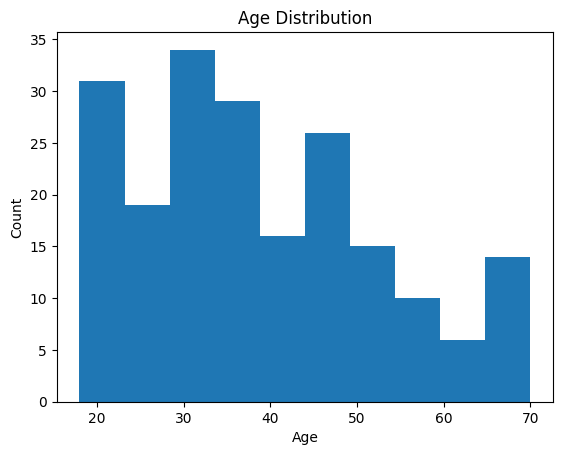

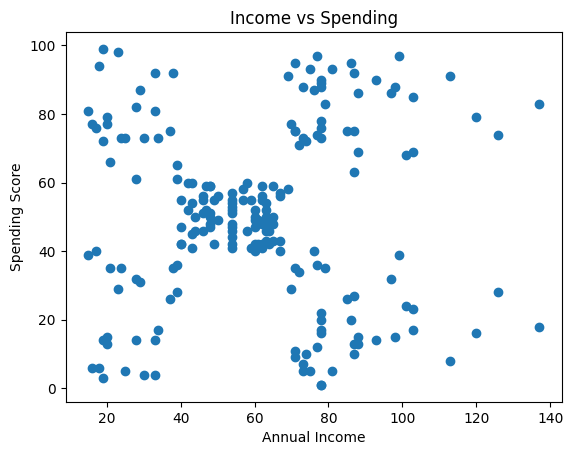

In [11]:
# Gender distribution baghne
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Age distribution
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Income vs Spending Score relation
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending")
plt.show()

#### Prepare Data for Clustering

In [ ]:
# Clustering sathi 2 main features gheto
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Data scale karne (important aahe clustering sathi)
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

#### Elbow Method (Best K find karne)

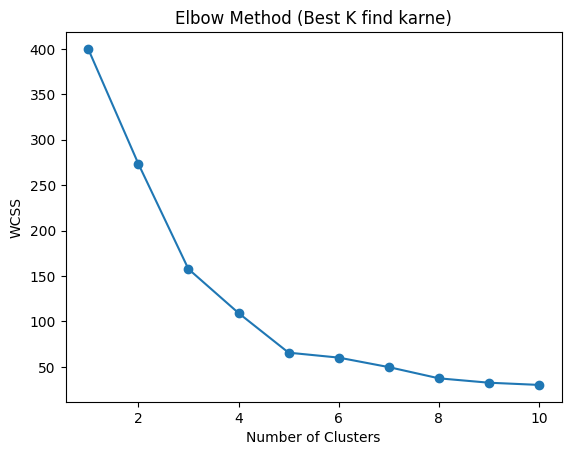

In [ ]:
# WCSS store karaycha (cluster tightness measure)
wcss = [] # Within-Cluster Sum of Squares (WCSS) list //प्रत्येक cluster मधल्या points आणि त्या cluster च्या center (centroid) मधला distance किती आहे याची total बेरीज

# 1 to 10 clusters try karun best K find karne
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # inertia_ gives the WCSS for the current number of clusters

# Graph plot karne
plt.plot(range(1, 11), wcss, marker='o') # Elbow method graph plot karne
plt.title("Elbow Method (Best K find karne)")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Note: Graph madhye elbow jithe bend disto, to best K (usually 5)

#### Apply K-Means Clustering

In [14]:
# KMeans model create karne (K=5 gheto)
kmeans = KMeans(n_clusters=5, random_state=42)

# Fit ani predict (cluster assign karne)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Updated dataset baghne
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


#### Cluster Visualization

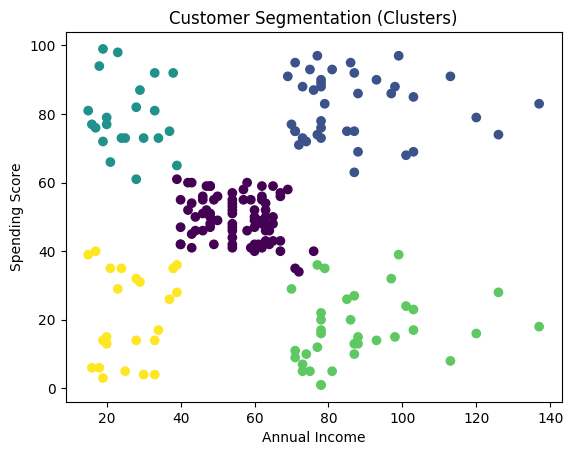

In [15]:
# Scatter plot madhye clusters display karne
plt.figure()

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation (Clusters)")

plt.show()

#### Cluster Insights

In [16]:
# Pratyek cluster cha average values baghne
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

# Output display
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


#### Classification (Cluster Predict karne)

In [ ]:
# Features (input)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Target (cluster number)
y = df['Cluster'] # Cluster number as target variable (0 to 4)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Logistic Regression model create karne
model = LogisticRegression(max_iter=200)

# Model train karne
model.fit(X_train, y_train)

# Prediction karne
y_pred = model.predict(X_test)

# Accuracy calculate karne
print("Classification Accuracy:", accuracy_score(y_test, y_pred))

Classification Accuracy: 0.975


c:\Users\jadha\OneDrive\Desktop\gpp\Internship\env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


I used K-Means Clustering to divide customers into 5 groups.

I used the Elbow Method to find the optimal number of clusters.

Customers with high income and high spending are categorized as premium customers.

Customers with low income and low spending are categorized as low-value customers.